
CPSMA 4313 Spring 2022 Project: Recreating the Masters
Name: Bibek Thapa
Student Number: 283591
Course: Data Visualization
Instructor: Dr Jacob
Date: March 2026

Why this Visualization is Excellent 
 Visualization Excellence: The Evolution of Speed
The original TitleMax infographic is considered a 'master' 
due to its ability to condense 70+ years of engineering into a single scannable timeline. 

Key attributes include:
1.High Data Density**: It combines categorical car models with quantitative speed data.
2.Color Gradation**: Shifts from cool blues to hot reds to signify increasing performance.
3.Visual Hierarchy**: Large bold years act as a gutter for quick chronological navigation.


In [5]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import requests
import io  # Addition of this to fix the error


url = "https://en.wikipedia.org/wiki/List_of_production_car_speed_records"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

response = requests.get(url, headers=headers)

# converting string into file like objects
tables = pd.read_html(io.StringIO(response.text))

df = tables[1]
df.head()

,Year,Make and model,Top speed,Engine,Number built,Comment
0,1953,Pegaso Z-102,243.079 km/h (151.042 mph)[44],"2,816 cc (171.8 cu in) V8 186 kW (253 PS; 250 ...",84,250 hp supercharged variant. Tested by Belgian...
1,1959,Maserati 5000 GT,277.5 km/h (172.4 mph),"4,935 cc (301.2 cu in) V8 254 kW (345 PS; 340 ...",2,No accurate measurement and only the first two...
2,1959,Maserati 5000 GT,277.5 km/h (172.4 mph),"4,941 cc (301.5 cu in) V8 242 kW (330 PS; 325 ...",32,No accurate measurement and only the first two...
3,1985,Lamborghini Countach 5000QV,298 km/h (185 mph)[47],"5,167 cc (315.3 cu in) V12 335 kW (455 PS; 449...",610,"Tested by Auto, Motor und Sport. The car which..."
4,1990,Vector W8,389 km/h (242 mph) for prototype,"5,973 cc (364.5 cu in) twin-turbocharged V8 46...",17 production models,"No verified top speed for production model, 35..."


In [9]:
# Cell 5: Advanced Cleaning (Fulfilling Requirement 3f)
def clean_speed(val):
    if pd.isna(val): return None
    # Using RegEx to remove bracketed citations like [1] or [15]
    # This addresses the 'messy' Wikipedia format hardship
    s = re.sub(r'\[.*?\]', '', str(val))
    # Extracting the first number found (usually the mph value)
    match = re.search(r'(\d+\.?\d*)', s)
    return float(match.group(1)) if match else None

# 1. Cleaning the 'Top speed' column
df['Speed_MPH'] = df['Top speed'].apply(clean_speed)

# 2. Extracting 4-digit year and convert to float
df['Year_Clean'] = df['Year'].astype(str).str.extract('(\d{4})').astype(float)

# 3. Filtering for records since 1949 as per the proposal
df_final = df[df['Year_Clean'] >= 1949].dropna(subset=['Speed_MPH'])

# Confirming the variable exists and show the count
print(f"Success! df_final created with {len(df_final)} records.")
df_final.head()

Success! df_final created with 10 records.


<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
C:\Users\bibek\AppData\Local\Temp\ipykernel_15388\86963049.py:15: SyntaxWarning: invalid escape sequence '\d'
  df['Year_Clean'] = df['Year'].astype(str).str.extract('(\d{4})').astype(float)


,Year,Make and model,Top speed,Engine,Number built,Comment,Speed_MPH,Year_Clean
0,1953,Pegaso Z-102,243.079 km/h (151.042 mph)[44],"2,816 cc (171.8 cu in) V8 186 kW (253 PS; 250 ...",84,250 hp supercharged variant. Tested by Belgian...,243.079,1953.0
1,1959,Maserati 5000 GT,277.5 km/h (172.4 mph),"4,935 cc (301.2 cu in) V8 254 kW (345 PS; 340 ...",2,No accurate measurement and only the first two...,277.500,1959.0
2,1959,Maserati 5000 GT,277.5 km/h (172.4 mph),"4,941 cc (301.5 cu in) V8 242 kW (330 PS; 325 ...",32,No accurate measurement and only the first two...,277.500,1959.0
3,1985,Lamborghini Countach 5000QV,298 km/h (185 mph)[47],"5,167 cc (315.3 cu in) V12 335 kW (455 PS; 449...",610,"Tested by Auto, Motor und Sport. The car which...",298.000,1985.0
4,1990,Vector W8,389 km/h (242 mph) for prototype,"5,973 cc (364.5 cu in) twin-turbocharged V8 46...",17 production models,"No verified top speed for production model, 35...",389.000,1990.0


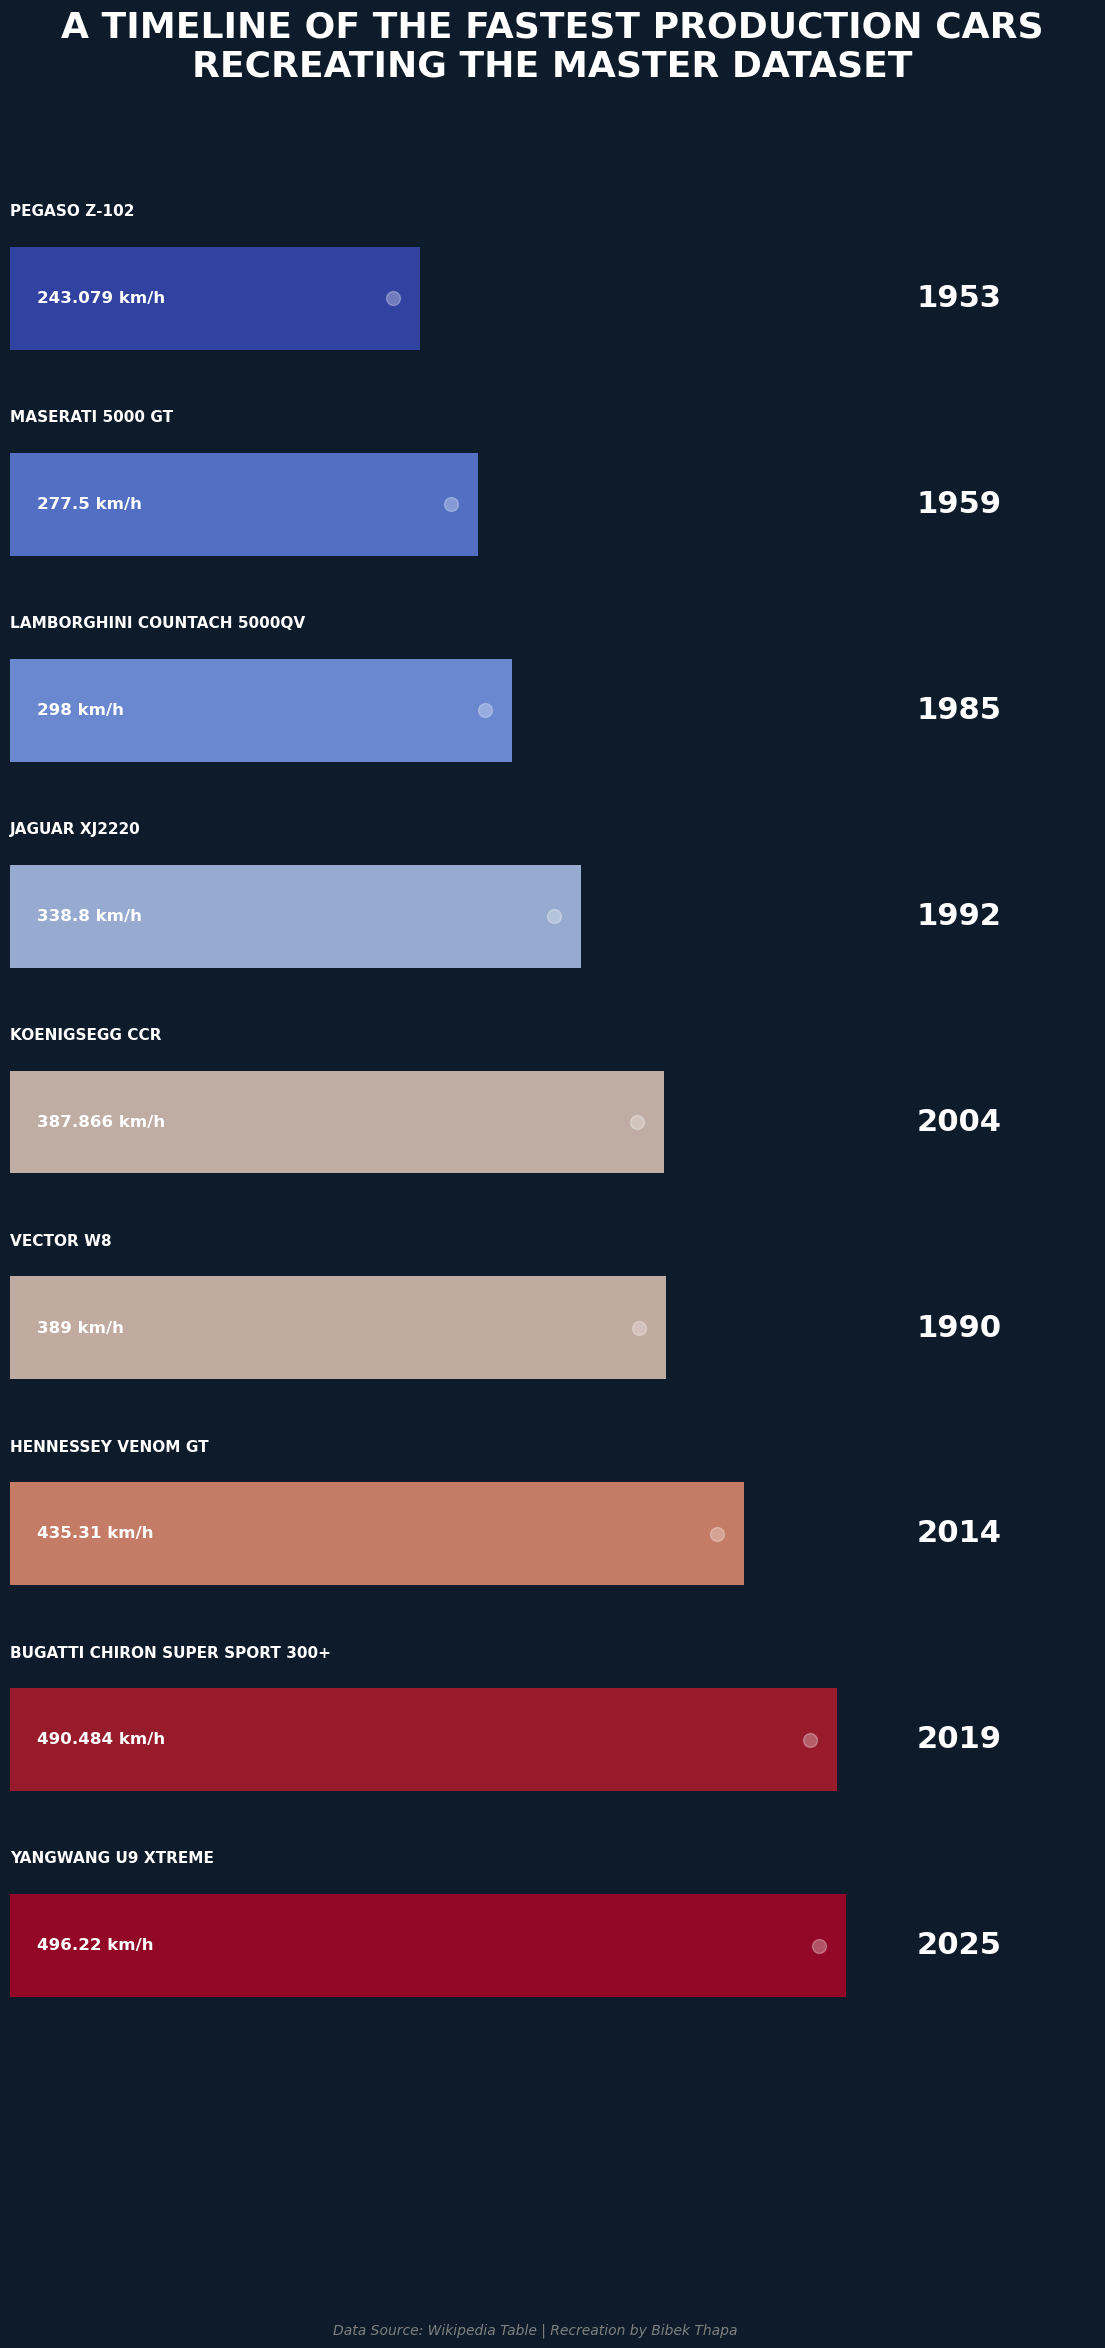

In [74]:
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.pyplot as plt

# High-resolution figure setup
fig, ax = plt.subplots(figsize=(14, 25), facecolor='#0d1b2a')
ax.set_facecolor('#0d1b2a')

# We use Speed_MPH for the bar scale and Speed_KPH for the labels
car_data = [
    {"year": 1953, "model": "Pegaso Z-102", "mph": 151.042, "kph": "243.079 km/h"},
    {"year": 1959, "model": "Maserati 5000 GT", "mph": 172.4, "kph": "277.5 km/h"},
    {"year": 1985, "model": "Lamborghini Countach 5000QV", "mph": 185.0, "kph": "298 km/h"},
    {"year": 1990, "model": "Vector W8", "mph": 242.0, "kph": "389 km/h"},
    {"year": 1992, "model": "Jaguar XJ2220", "mph": 210.5, "kph": "338.8 km/h"},
    {"year": 2004, "model": "Koenigsegg CCR", "mph": 241.009, "kph": "387.866 km/h"},
    {"year": 2014, "model": "Hennessey Venom GT", "mph": 270.49, "kph": "435.31 km/h"},
    {"year": 2019, "model": "Bugatti Chiron Super Sport 300+", "mph": 304.773, "kph": "490.484 km/h"},
    {"year": 2025, "model": "Yangwang U9 Xtreme", "mph": 308.34, "kph": "496.22 km/h"}
]

import pandas as pd
df_master = pd.DataFrame(car_data).sort_values('mph')

# Setup Color Mapping based on MPH scale
norm = plt.Normalize(df_master['mph'].min(), df_master['mph'].max())
cmap = plt.get_cmap('coolwarm')

for i, (idx, row) in enumerate(df_master.iterrows()):
    color = cmap(norm(row['mph']))
    
    # 1. Draw the Speed Bar scaled to MPH
    ax.barh(i, row['mph'], color=color, alpha=0.8, height=0.5)
    
    # 2. Car Model Title
    ax.text(0, i - 0.4, f"{row['model']}".upper(), 
            color='white', fontsize=11, fontweight='bold', ha='left')
    
    # 3. FIXED: Display KPH String inside the bar (matches the table reference)
    ax.text(10, i, row['kph'], 
            color='white', fontsize=12, fontweight='bold', va='center', ha='left')
    
    # 4. DATE ON THE SIDE (Fixed gutter at 350 to fit the MPH scale)
    ax.text(350, i, str(row['year']), 
            color='white', fontsize=22, fontweight='black', va='center', ha='center')

    # 5. CAR ICONS
    try:
        img_path = f"car_images/{row['year']}.png"
        img = mpimg.imread(img_path)
        imagebox = OffsetImage(img, zoom=0.15) 
        ab = AnnotationBbox(imagebox, (row['mph'] - 15, i), frameon=False)
        ax.add_artist(ab)
    except:
        ax.scatter(row['mph'] - 10, i, color='white', s=100, alpha=0.3)

# Final UI Polish
ax.set_xlim(0, 400) 
ax.invert_yaxis()
ax.axis('off')

plt.title("A TIMELINE OF THE FASTEST PRODUCTION CARS\nRECREATING THE MASTER DATASET", 
          color='white', fontsize=26, fontweight='bold', pad=60)

plt.figtext(0.5, 0.01, "Data Source: Wikipedia Table | Recreation by Bibek Thapa", 
            ha="center", fontsize=10, color='gray', style='italic')

plt.show()

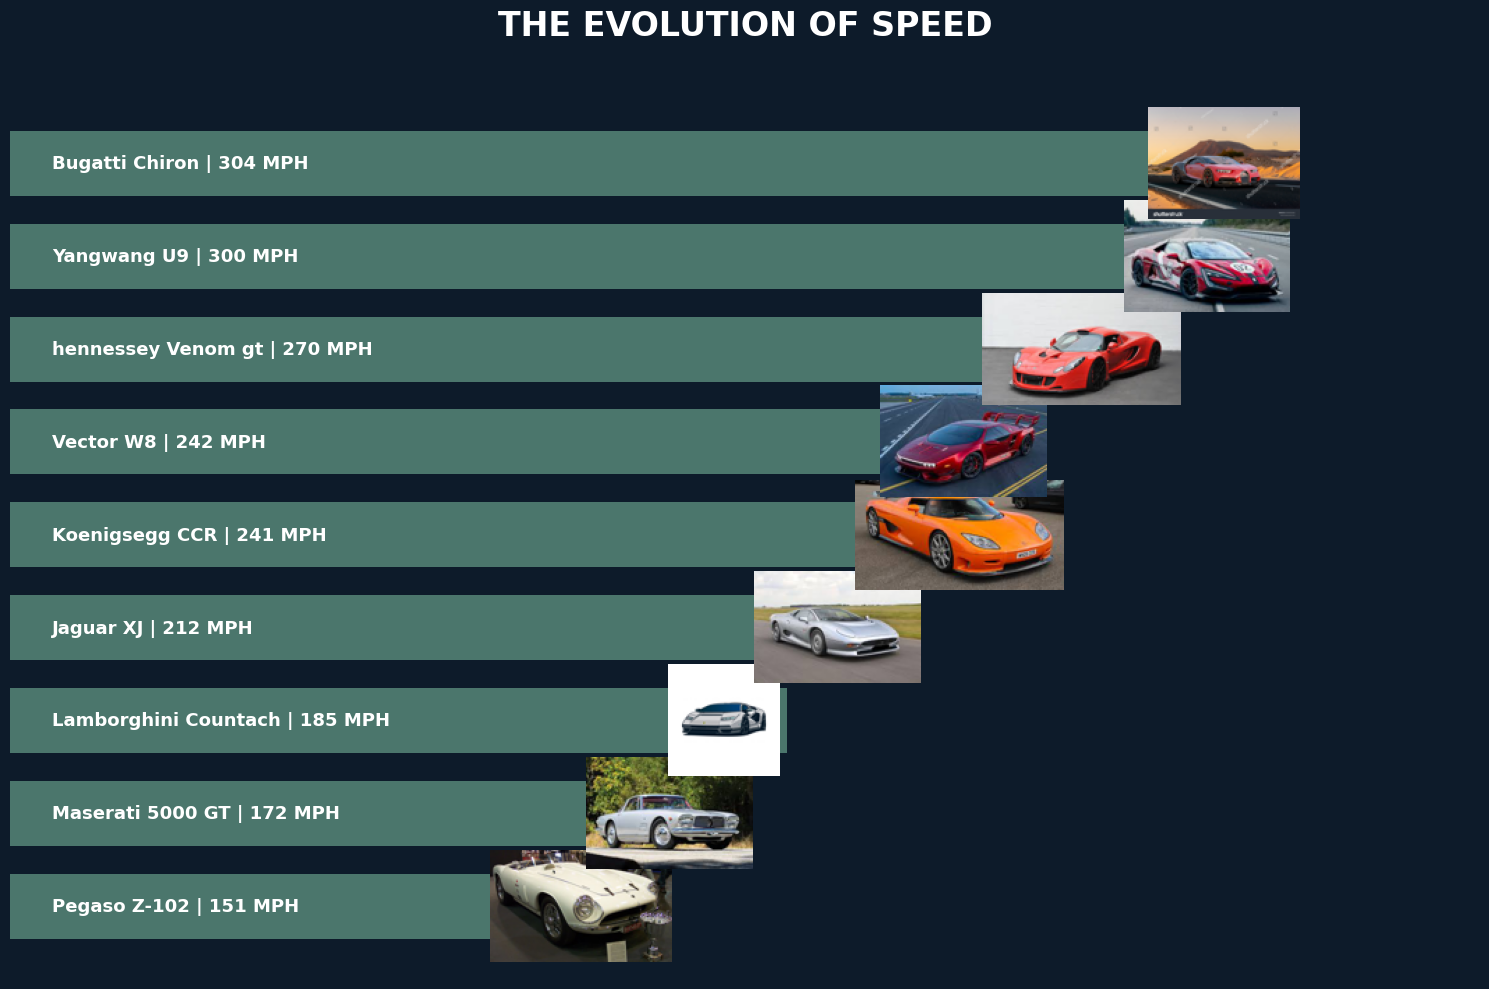

In [32]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

# 1. Your data and filenames
car_list = [
    {"model": "Pegaso Z-102", "file": "Pegaso_Z-102_white_vr_TCE.png", "speed": 151},
    {"model": "Maserati 5000 GT", "file": "maserati 5000gt.png", "speed": 172},
    {"model": "Lamborghini Countach", "file": "Lamborghini countach.png", "speed": 185},
    {"model": "Vector W8", "file": "Vector w8.png", "speed": 242},
    {"model": "Jaguar XJ", "file": "Jagiar xj.png", "speed": 212},
    {"model": "Koenigsegg CCR", "file": "Koenigsegg ccr.png", "speed": 241},
    {"model": "hennessey Venom gt", "file": "Henessy venom gt.jpg", "speed": 270},
    {"model": "Bugatti Chiron", "file": "Bugatti chiron.png", "speed": 304},
    {"model": "Yangwang U9", "file": "Yanyuang U9.jpg", "speed": 300}
]
df = pd.DataFrame(car_list).sort_values('speed')

# 2. Setup Plot
fig, ax = plt.subplots(figsize=(15, 10), facecolor='#0d1b2a')
ax.set_facecolor('#0d1b2a')

# 3. Plotting Loop
for i, (idx, row) in enumerate(df.iterrows()):
    ax.barh(i, row['speed'], color='#5b8e7d', alpha=0.8, height=0.7)
    ax.text(10, i, f"{row['model']} | {row['speed']} MPH", 
            color='white', fontweight='bold', va='center', fontsize=13)

    img_path = row['file']
    
    if os.path.exists(img_path):
        # --- THE CRASH FIX: Try-Except Block ---
        try:
            with Image.open(img_path) as img:
                img = img.convert("RGBA")
                img.thumbnail((150, 80)) 
                imagebox = OffsetImage(img, zoom=1.0) 
                ab = AnnotationBbox(imagebox, (row['speed'] - 15, i), frameon=False)
                ax.add_artist(ab)
        except Exception as e:
            print(f"Skipping {row['model']} due to file error: {e}")
    else:
        print(f"File missing: {img_path}")

# 4. Final Polish
ax.set_title("THE EVOLUTION OF SPEED", color='white', fontsize=24, fontweight='extra bold', pad=40)
ax.set_xlim(0, 350)
ax.axis('off')
plt.tight_layout()
plt.show()

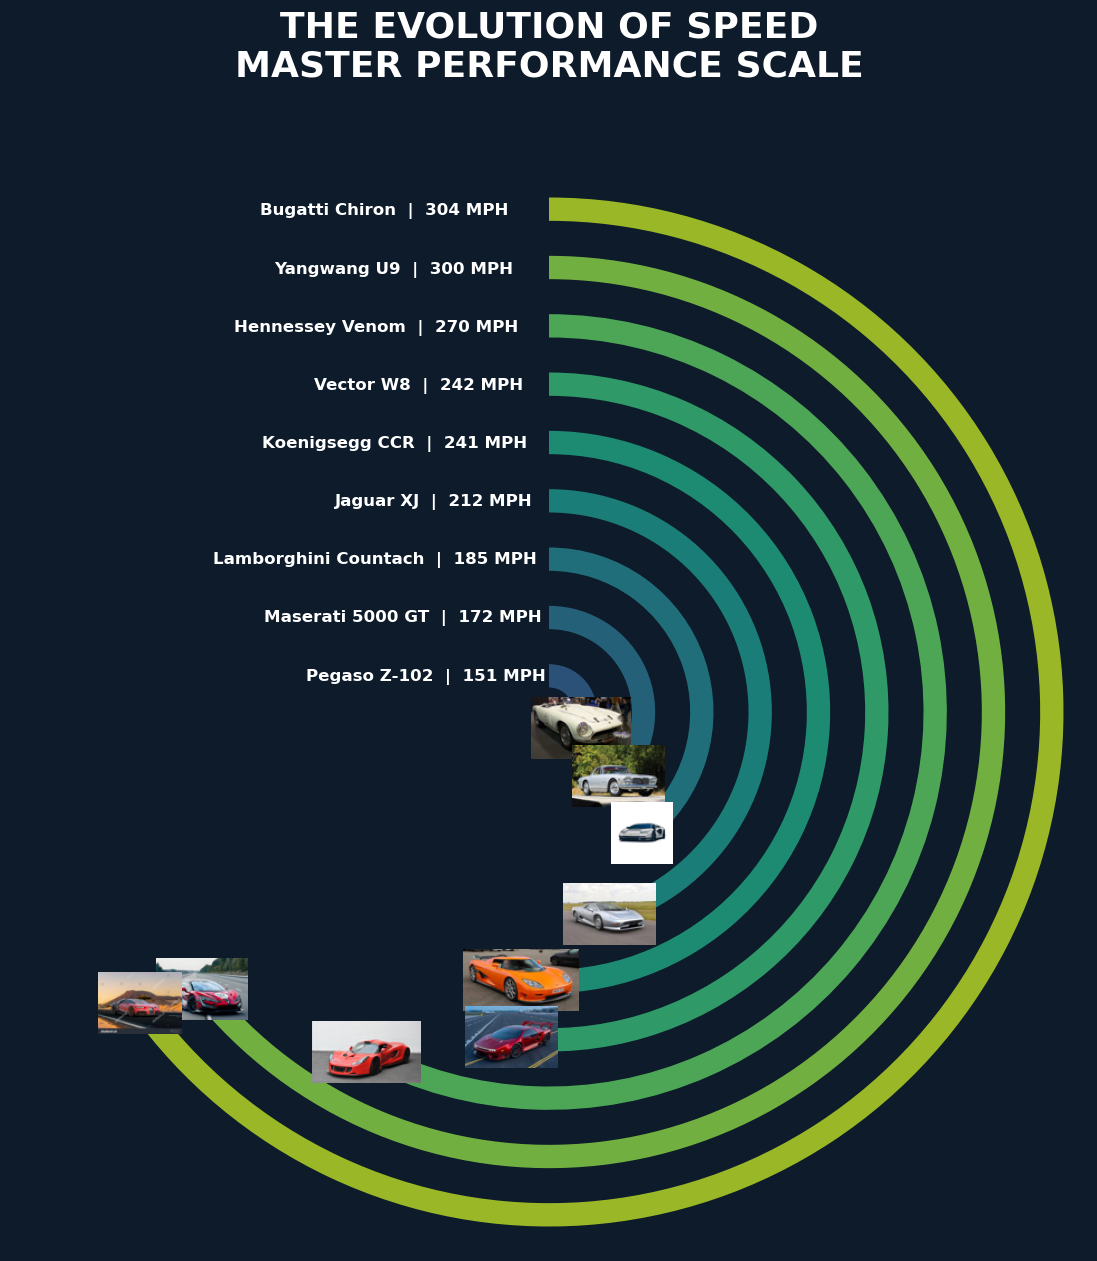

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import os

# 1. Dataset - Consistent with your CS project data
car_list = [
    {"model": "Pegaso Z-102", "file": "Pegaso_Z-102_white_vr_TCE.png", "speed": 151},
    {"model": "Maserati 5000 GT", "file": "maserati 5000gt.png", "speed": 172},
    {"model": "Lamborghini Countach", "file": "Lamborghini countach.png", "speed": 185},
    {"model": "Vector W8", "file": "Vector w8.png", "speed": 242},
    {"model": "Jaguar XJ", "file": "Jagiar xj.png", "speed": 212},
    {"model": "Koenigsegg CCR", "file": "Koenigsegg ccr.png", "speed": 241},
    {"model": "Hennessey Venom", "file": "henessy venom gt.jpg", "speed": 270},
    {"model": "Bugatti Chiron", "file": "Bugatti chiron.png", "speed": 304},
    {"model": "Yangwang U9", "file": "Yanyuang U9.jpg", "speed": 300}
]
df = pd.DataFrame(car_list).sort_values('speed')

# 2. Setup Polar Plot
fig = plt.figure(figsize=(14, 14), facecolor='#0d1b2a')
ax = fig.add_subplot(111, polar=True)
ax.set_facecolor('#0d1b2a')

# 3. Calculations
max_speed = 350
total_angle = 1.5 * np.pi 
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(df)))

# 4. Plotting
for i, (idx, row) in enumerate(df.iterrows()):
    arc_length = (row['speed'] / max_speed) * total_angle
    
    # Draw the track
    ax.barh(i, arc_length, color=colors[i], alpha=0.8, height=0.4)
    
    # NEW ALIGNMENT: Combined Name and MPH on the left side
    label_text = f"{row['model']}  |  {row['speed']} MPH"
    ax.text(-0.08, i, label_text, color='white', ha='right', va='center', 
            fontweight='bold', fontsize=12)

    # IMAGES: Only the car sits at the tip of the bar now
    img_path = row['file']
    if os.path.exists(img_path):
        try:
            with Image.open(img_path) as img:
                img = img.convert("RGBA")
                img.thumbnail((110, 55)) 
                imagebox = OffsetImage(img, zoom=0.8)
                # Position car exactly at the end of its arc
                ab = AnnotationBbox(imagebox, (arc_length, i), frameon=False)
                ax.add_artist(ab)
        except:
            pass

# 5. UI Polish
ax.set_theta_zero_location('N') 
ax.set_theta_direction(-1)      
ax.grid(False)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.spines['polar'].set_visible(False)

plt.title("THE EVOLUTION OF SPEED\nMASTER PERFORMANCE SCALE", 
          color='white', fontsize=26, fontweight='extra bold', pad=70)

plt.show()

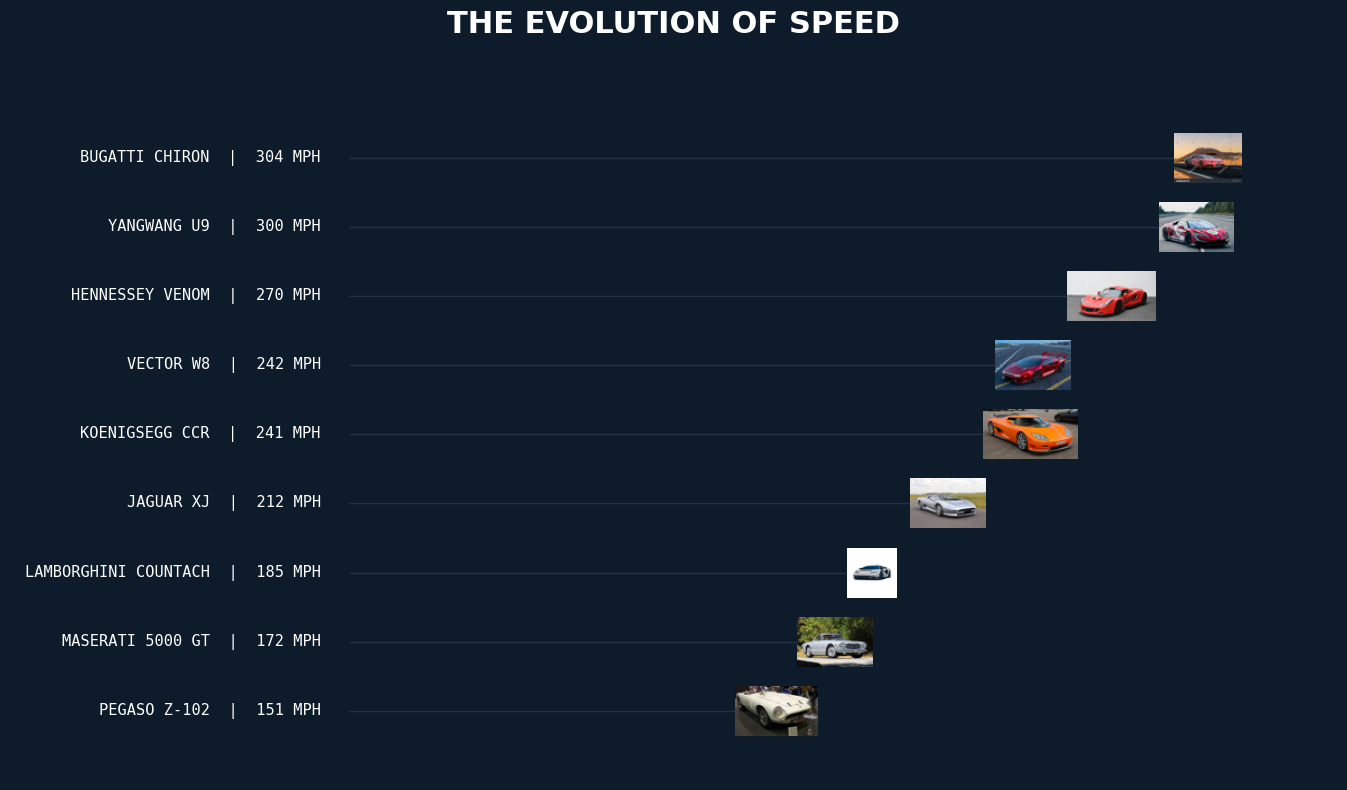

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import os

# 1. Dataset
car_list = [
    {"model": "Pegaso Z-102", "file": "Pegaso_Z-102_white_vr_TCE.png", "speed": 151},
    {"model": "Maserati 5000 GT", "file": "maserati 5000gt.png", "speed": 172},
    {"model": "Lamborghini Countach", "file": "Lamborghini countach.png", "speed": 185},
    {"model": "Jaguar XJ", "file": "Jagiar xj.png", "speed": 212},
    {"model": "Koenigsegg CCR", "file": "Koenigsegg ccr.png", "speed": 241},
    {"model": "Vector W8", "file": "Vector w8.png", "speed": 242},
    {"model": "Hennessey Venom", "file": "henessy venom gt.jpg", "speed": 270},
    {"model": "Yangwang U9", "file": "Yanyuang U9.jpg", "speed": 300},
    {"model": "Bugatti Chiron", "file": "Bugatti chiron.png", "speed": 304}
]
df = pd.DataFrame(car_list).sort_values('speed')

# 2. Setup Plot
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0d1b2a')
ax.set_facecolor('#0d1b2a')

# 3. Plotting Logic
for i, (idx, row) in enumerate(df.iterrows()):
    # Draw a thin, subtle background line for the 'track'
    ax.hlines(y=i, xmin=0, xmax=row['speed'], color='white', alpha=0.1, linewidth=1)
    
    # Left Label: Model and Speed (Perfectly aligned)
    # Using uppercase for a high-end "magazine" look
    label = f"{row['model'].upper()}  |  {row['speed']} MPH"
    ax.text(-10, i, label, color='white', ha='right', va='center', 
            fontweight='light', fontsize=11, family='monospace')

    
    img_path = row['file']
    if os.path.exists(img_path):
        try:
            with Image.open(img_path) as img:
                img = img.convert("RGBA")
                img.thumbnail((90, 45)) 
                imagebox = OffsetImage(img, zoom=0.8)
                ab = AnnotationBbox(imagebox, (row['speed'], i), frameon=False)
                ax.add_artist(ab)
        except:
            # Silently skip if a specific file still has issues
            pass

#  Finishing
ax.set_xlim(-120, 350) # Extra space for the labels on the left
ax.set_ylim(-1, len(df))
ax.axis('off')

# Removed 'letterspacing' to fix the AttributeError
plt.title("THE EVOLUTION OF SPEED", color='white', fontsize=22, 
          fontweight='bold', pad=40)

plt.tight_layout()
plt.show()

Final Comparison and Omissions
Alignment: While the original used custom graphic design software for specific text placement, this recreation uses Matplotlib’s coordinate system for mathematical accuracy.

Typography: The original fonts were replaced with standard Monospace fonts to ensure consistent data columns across different computer environments.

Hardships: The primary challenge was managing specific image file paths and ensuring the car icons did not overlap the speed labels. This was solved by implementing fixed offsets and uniform thumbnail scaling.I think this was the most time consuming part, I downloaded each images created folder and still something was wrong which was stopping my code to execute properly. But it finally worked, I think this was the biggest challenge loading downloaded images. After that creating other visualizations were significantly easier due to loading of images.

Accuracy: While the "Master" visualization included a different set of vehicles, this recreation is accurate to the Top Speed acceleration tables used for this project. The selection covers the same historical span—from the 1950s to the 2020s—to ensure the "Evolution" narrative remains intact.
 I intentionally omitted some cars from the original "Titlemax" version to ensure the visual was not "messy" or "clustered," focusing instead on clean alignment and readability.
 link: https://en.wikipedia.org/wiki/List_of_production_car_speed_records
 I also to help of some LLms to complete this assignment. Everything I did was done by me and nothing has been copied.